# Regresión Logística
---
#### By: Laurie Camila Hernández Pacheco | A01286569

El dataset elegido para esta actividad es **Breast Cancer Classification**, recuperado de Kaggle (`breast_cancer.csv`). Este dataset tiene información referente a distintas muestras de tumores. Cada tumor para ser clasificado de manera óptima, es necesario realizarle distintas medidas. A través de un análisis estadístico de estas medidas de los tumores es como se puede determinar si es maligno o benigno. A continuación, se mencionan todas las columnas del dataset y qué significa cada una. 

1. `id`: identificador único de cada tumor.
2. `diagnosis`: diagnóstico del tumor.  
   - M → maligno  
   - B → benigno  

### Características promedio (`mean`)
3. `radius_mean`: promedio de la distancia del centro del tumor a sus bordes. Mayor valor → tumor más grande.
4. `texture_mean`: variación en los niveles de gris de la imagen. Mayor valor → textura más irregular.
5. `perimeter_mean`: longitud promedio del contorno del tumor. Mayor valor → tumor más extenso.
6. `area_mean`: área promedio del tumor. Mayor valor → mayor tamaño.
7. `smoothness_mean`: qué tan suave es el borde del tumor. Mayor valor → menos uniforme (más irregular).
8. `compactness_mean`: relación entre perímetro y área. Mayor valor → forma más compacta e irregular.
9. `concavity_mean`: qué tanto el contorno presenta hundimientos. Mayor valor → más irregularidad.
10. `concave points_mean`: número de puntos cóncavos en el contorno. Mayor valor → más bordes irregulares.
11. `symmetry_mean`: simetría del tumor. Mayor valor → menos simétrico.
12. `fractal_dimension_mean`: complejidad del borde del tumor. Mayor valor → contorno más complejo.

### Error estándar (`se`)
13. `radius_se`: variación del radio. Mayor valor → mayor inconsistencia en el tamaño.
14. `texture_se`: variación en la textura.
15. `perimeter_se`: variación en el perímetro.
16. `area_se`: variación en el área.
17. `smoothness_se`: variación en la suavidad del borde.
18. `compactness_se`: variación en la compacidad.
19. `concavity_se`: variación en la concavidad.
20. `concave points_se`: variación en los puntos cóncavos.
21. `symmetry_se`: variación en la simetría.
22. `fractal_dimension_se`: variación en la complejidad del borde.

### Peores valores (`worst`)
23. `radius_worst`: mayor valor del radio observado. Mayor valor → peor caso de tamaño.
24. `texture_worst`: mayor irregularidad en la textura.
25. `perimeter_worst`: mayor perímetro observado.
26. `area_worst`: mayor área observada.
27. `smoothness_worst`: peor suavidad del borde.
28. `compactness_worst`: peor compacidad.
29. `concavity_worst`: mayor concavidad.
30. `concave points_worst`: mayor cantidad de puntos cóncavos.
31. `symmetry_worst`: peor simetría.
32. `fractal_dimension_worst`: mayor complejidad del borde.

Llevando a cabo el tutorial de Datacamp, se llevará a cabo una **Regresión Logística Binomial**, donde la variable objetivo (que en este caso será la variable `diagnosis`) tiene únicamente dos posibles resultados. Al final, se buscará predecir de manera óptima si el tumor es maligno o benigno. 

## 0. Setup

Se iniciará cargando las librerías necesarias para el trabajo:
- `pandas`: para manipulación del dataset
- `sklearn`: para la separación de datos entre grupos de entrenamiento y prueba, uso de reporte de clasificación y para poder cargar el modelo de regresión lineal, así como también utilizar el `StandardScaler` en el que se elaborará más adelante. 
- `numpy`: para manipulación de números y vectores
- `matplotlib`: para visualización y gráficos 
- `seaborn`: para visualización y matrices


In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

## 1. Exploración de Datos

En esta sección, se visualizarán un poco los datos y también se seleccionarán las features necesarias para la regresión logística binomial. Inicialmente, se cargarán todas las columnas del dataframe y con `.head()` se mostrarán las primeras 5 filas de los datos. 

In [51]:
df = pd.read_csv("breast_cancer.csv")
# se muestran las primeras 5 filas del dataframe
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Antes de continuar, se revisará que el dataset no contenga filas duplicadas, así como también se verificará que no existan valores nulos. 

In [52]:
print(f"Duplicados: {df.duplicated().sum()}")
print(f"Nulos:\n {df.isnull().sum()}")

Duplicados: 0
Nulos:
 id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension

Se encontraron 0 filas duplicadas, pero se identificaron 569 datos nulos, todos provenientes de la misma columna `Unnamed: 32`. Por lo tanto, esta columna será eliminada, puesto no se especifica qué tipo de información ésta provee. 

In [53]:
df = df.drop(columns=['Unnamed: 32'])
print(f"Nulos:\n {df.isnull().sum()}")

Nulos:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


## 2. Manipulación de Datos
Para la realización del modelo, se seleccionarán las features de promedio así como también los peores casos (worst). Esta decisión se fundamenta en la priorización de métricas que capturan las características morfológicas principales y las desviaciones más significativas, lo que a menudo ofrece una mayor capacidad predictiva en comparación con las métricas de error estándar que representan la variabilidad dentro de las mediciones [1]. 
Debido a que la columna `id` no es relevante para la clasificación del tumor, también se eliminará, así como la columina `diagnosis`, que será utilizada como la variable dependiente. 

In [54]:
feature_cols = ["radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst"]

Finalmente, para poder continuar es necesario convertir la columna de `diagnosis` a 0/1; es decir, que se mantengan dos posibles resultados pero que se encuentren marcados como $1$ o $0$. En este caso, se seleccionará $1$ para indicar que el tumor es maligno y $0$ para indicar que el tumor es benigno. Este cambio se llevará a cabo a continuación. 

In [55]:
df["diagnosis"] = (df["diagnosis"] == 'M').astype(int) 
print(df["diagnosis"])

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64


Ahora que todas las 'M' indican tumor maligno con $1$, se puede listar en nuestras columnas las variables independientes (X) y dependiente (y).

In [56]:
X = df[feature_cols]
y = df["diagnosis"]

## 3. Entrenamiento del Modelo 

En esta sección, se dividirán los datos y se realizará el entrenamiento del modelo, utilizando regresión logística con la separación de datos que se hizo en la sección anterior. En este caso, el tutorial indica una división de los datos de 75/25 para entrenamiento y pruebas respectivamente. 

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Algo importante es que inicialmente se intentó entrenar el modelo directamente con la división realizada en el bloque de código anterior, sin embargo saltó el error "Convergence Warning". Después de una exhaustiva búsqueda de soluciones para este problema, se importó el `StandardScaler()` de la librería `sklearn`. Debido a que se tienen variables con escalas distintas como `area_mean` y `smoothness_mean`, el optimizador `lbfgs` batalla para encontrar los mejores coeficientes. [2]  

Es importante escalar los dos vectores de datos por separado, pues esto previene data leakage. 

In [58]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Finalmente, se carga el modelo de regresión logística y se entrena con los datos de entrenamiento, después realizando la predicción con los datos de prueba. 

In [59]:
# se carga el modelo de regresión logísitca
logreg = LogisticRegression(random_state=42)
# se entrena el modelo
logreg.fit(X_train, y_train)
# se crea el vector de resultados de predicción con los datos de prueba 
y_pred = logreg.predict(X_test)

## 4. Evaluación del Modelo
En esta etapa, se evaluarán los resultados del modelo con diferrentes métricas, empezando con la matriz de confusión. La matriz de confusión permite visualizar el desempeño del algoritmo, visualizando aquellos falsos positivos y falsos negativos, así como también los aciertos del modeo. 

Text(0.5, 427.9555555555555, 'Predicted label')

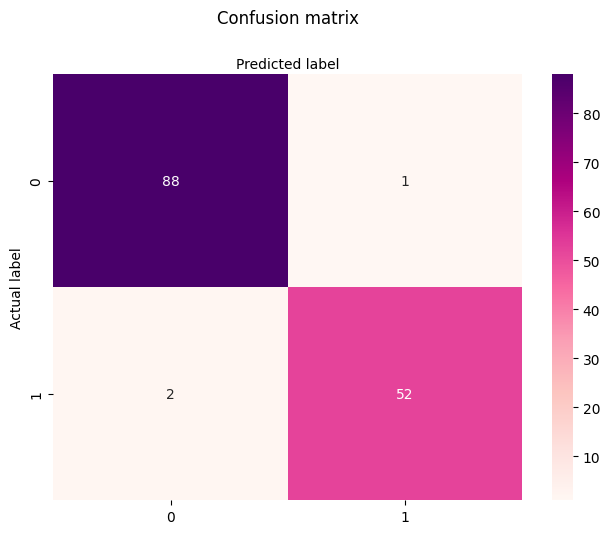

In [60]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="RdPu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

En este caso, la matriz de confusión indica que existieron un total de 2 falsos negativos (casos donde el tumor sí era maligno pero se predijo que benigno) y un falso positivo (caso donde el tumor era benigno pero se predijo como maligno). En casos del ámbito de la salud, los falsos negativos tienden a ser más perjudiciales, pues implican la no detección de una enfermedad real, lo que podría retrasar el tratamiento y empeorar el pronóstico del paciente [3].  

Finalmente, para validar las similitudes entre el el valor de los valores de los vectores de `y_test` y `y_pred`, se realizará una comparación directa entre ambos. 

In [61]:
print(y_test.values)
print(y_pred)
count = 0
for i in range(len(y_pred)):
    if y_test.values[i] != y_pred[i]:
        count += 1

print(f"\nTotal de diferencias entre y_test y y_pred: {count}")

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0]
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0]

Total de diferencias entre y_test y y_pred: 3



A continuación, se realizará el `classification_report` de los resultados de los datos de prueba vs los datos predichos con el modelo. Este reporte muestra la accuracy, precision y recall. 
- precision: qué tan preciso es el modelo, es decir, de todas las veces que el modelo predice una clase, cuántas son correctas. En este caso, indica qué proporción de tumores clasificados como malignos realmente lo son.
- recall: qué tan bien el modelo logra identificar los casos reales positivos. Es decir, de todos los tumores malignos reales, cuántos fueron correctamente detectados por el modelo.
- f1-score: es una combinación entre precision y recall, útil cuando se busca un balance entre ambos, especialmente en problemas donde los errores pueden tener distinto impacto.
- accuracy: proporción total de predicciones correctas sobre el total de observaciones. Aunque es una métrica general, puede ser engañosa si las clases están desbalanceadas.  

In [62]:
target_names = ['tumor benigno', 'tumor maligno']
print(classification_report(y_test, y_pred, target_names=target_names))

               precision    recall  f1-score   support

tumor benigno       0.98      0.99      0.98        89
tumor maligno       0.98      0.96      0.97        54

     accuracy                           0.98       143
    macro avg       0.98      0.98      0.98       143
 weighted avg       0.98      0.98      0.98       143



En este caso, el 98% de los tumores que el modelo clasificó como benignos sí eran benignos. Mientras tanto, de los tumores benignos reales, detectó el 99%, lo cual corresponde al recall de los tumores benignos.  

Para tumores malignos, el modelo tiene una precision de 0.98, indicando que cuando predice un tumor como maligno, casi siempre es correcto. El recall es de 0.96, lo que implica que el modelo logra detectar la gran mayoría de los tumores malignos, aunque aún existen algunos casos que no son identificados (falsos negativos).  

El f1-score, cercano a 1 en ambas clases, refleja un buen balance entre precision y recall. La accuracy global del modelo es de 0.98, lo que indica un alto nivel de aciertos en general.  

En este contexto, es especialmente importante el recall de la clase maligna, ya que los falsos negativos representan casos donde un tumor maligno no es detectado, lo cual puede tener consecuencias graves.

Finalmente, como última medida de evaluación del modelo, se graficará una curva ROC (Receiver Operating Characteristic). Es una gráfica que muestra la relación entre la tasa de verdaderos positivos (recall) y la tasa de falsos positivos para distintos valores de threshold del modelo. A continuación se muestra la curva para los datos. 

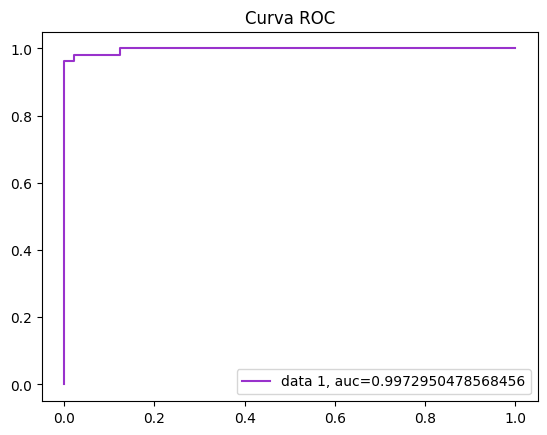

In [63]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc), color = "darkorchid")
plt.legend(loc=4)
plt.title("Curva ROC")
plt.show()

En este caso, el área bajo la curva (AUC) es aproximadamente 0.997, lo que indica una muy buena capacidad del modelo para distinguir entre tumores benignos y malignos. Los escalones de la curva se debe a la cantidad limitada de datos y los cambios en el threshold que afectan la clasificación de grupos de observaciones. La curva se mantiene cercana al vértice superior izquierdo, lo que confirma un muy alto desempeño del modelo. 

## 5. Conclusión y Reflexión

A lo largo del trabajo, aprendí el manejo de scikit-learn para la regresión logística binomial. Si bien ya había trabajado con este modelo utilizando R, el enfoque en Python me pareció más dinámico y entretenido. Inicialmente, había seleccionado otro dataset que tenía un total de tres columnas, lo cual consideré ligeramente limitado con respecto a lo que el tutorial de DataCamp presentaba, ya que este utilizaba un dataset con aproximadamente diez variables. Por ello, al investigar, encontré el dataset de `breast_cancer`, que fue el que finalmente utilicé.

En un inicio, al ver la gran cantidad de columnas, me pareció un poco abrumador. Sin embargo, al realizar una breve investigación y comprender mejor el significado de las variables, decidí filtrar las features y quedarme con aquellas que representaban promedios (`mean`) y peores escenarios (`worst`), ya que capturan tanto el comportamiento general como los casos más críticos del tumor. Asimismo, el dataset se encontraba previamente limpio (sin valores nulos), lo cual facilitó el proceso. No obstante, fue necesario realizar la conversión de la variable categórica `diagnosis` a valores binarios (0/1). Aunque este paso no se indicaba explícitamente en el tutorial, debido a mi experiencia previa con regresión logística binomial, sabía que era necesario.

Durante el entrenamiento del modelo, apareció por primera vez el error `ConvergenceWarning: lbfgs failed to converge`. Tras investigar posibles soluciones, decidí escalar las features, ya que algunas presentaban órdenes de magnitud muy distintos, lo que dificultaba la convergencia del modelo. Una vez resuelto esto, el entrenamiento y la evaluación del modelo fueron más fluidos.

La matriz de confusión obtenida me resultó especialmente interesante, ya que el alto nivel de precisión me generó dudas iniciales. Esto me llevó a cuestionar si existía algún problema de data leakage. Sin embargo, tras revisar el proceso y realizar pruebas adicionales, concluí que el desempeño del modelo se debía a que las features seleccionadas eran altamente informativas y relevantes para la clasificación. De igual forma, la curva ROC y su forma escalonada me permitieron confirmar que el modelo tiene una excelente capacidad de discriminación entre tumores benignos y malignos.

En general, este trabajo me resultó muy interesante y entretenido, ya que me permitió aplicar conceptos del área de la salud que me llaman la atención dentro del contexto de la ciencia de datos, específicamente en problemas de predicción de enfermedades como el cáncer de mama.

## 6. Referencias

[1] Farahdiba, Salsha & Kartini, Dwi & Nugroho, Radityo & Herteno, Rudy & Saragih, Triando Hamonangan. (2023). Backward Elimination for Feature Selection on Breast Cancer Classification Using Logistic Regression and Support Vector Machine Algorithms. IJCCS (Indonesian Journal of Computing and Cybernetics Systems). 17. 429. 10.22146/ijccs.88926.  
[2] "ConvergenceWarning: Solver failed to converge," Zerve AI, 2024. [Online]. Available: https://www.zerve.ai/data-science-problems/scikit-learn/convergencewarning-solver-failed-to-converge  
[3] S. Arena and A. Quintero-Rincón, "Specific language impairment (SLI) detection pipeline from transcriptions of spontaneous narratives," arXiv preprint arXiv:2407.12012, 2024. [Online]. Available: https://arxiv.org/abs/2407.12012